# 📊 Phase 3 – Exploratory Data Analysis (EDA)
## Section: Overview Analysis

In [1]:
# Load dataset and inspect the first 5 rows
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Read dataset
df = pd.read_excel(r'C:\Users\theha\OneDrive\Desktop\Projects\1. Global AI Job Market & Salary Trends 2025\Dataset\cleaned_data_by_Python.xlsx')

# Screening of data structure
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,posting_month,posting_year,posting_quarter,required_skills_filled
0,AI00001,AI Research Scientist,90376.0,USD,SE,CT,China,M,China,50,...,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,10,2024,2024Q4,"Tableau, PyTorch, Kubernetes, Linux, NLP"
1,AI00002,AI Software Engineer,102550.0,USD,EN,CT,Canada,M,Ireland,100,...,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,11,2024,2024Q4,"Deep Learning, AWS, Mathematics, Python, Docker"
2,AI00003,AI Specialist,152626.0,USD,MI,FL,Switzerland,L,South Korea,0,...,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,3,2025,2025Q1,"Kubernetes, Deep Learning, Java, Hadoop, NLP"
3,AI00004,NLP Engineer,80215.0,USD,SE,FL,India,M,India,50,...,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems,12,2024,2024Q4,"Scala, SQL, Linux, Python"
4,AI00005,AI Consultant,54624.0,EUR,EN,PT,France,S,Singapore,100,...,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,4,2025,2025Q2,"MLOps, Java, Tableau, Python"


## 1. Initial Screening of Data

**Findings:** The dataset includes multiple variables related to the global AI job market, such as `job_id`, `job_title`, `salary_usd`, `experience_level`, `employment_type`, `company_location`, `employee_residence`, `remote_ratio`, `industry`, `posting_date`, `application_deadline`, `benefits_score`, etc.

**Interpretation:** Confirms that the dataset was loaded successfully and provides an overview of the key information available for further analysis (salary, job type, experience level, company size, country, etc.).

In [2]:
# Check data shape after Preprocessing
print(f"Shape of cleaned data: {df.shape}")

# Screen data info
df.info()

Shape of cleaned data: (15010, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15010 entries, 0 to 15009
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15010 non-null  object        
 1   job_title               15010 non-null  object        
 2   salary_usd              15010 non-null  float64       
 3   salary_currency         15010 non-null  object        
 4   experience_level        15010 non-null  object        
 5   employment_type         15010 non-null  object        
 6   company_location        15010 non-null  object        
 7   company_size            15010 non-null  object        
 8   employee_residence      15010 non-null  object        
 9   remote_ratio            15010 non-null  int64         
 10  required_skills         15010 non-null  object        
 11  education_required      15010 non-null  object        
 12  years_exper

## 2. Checking Data Shape and Structure

**Findings:** The dataset contains 15,010 rows × 23 columns, with no missing values.

**Numerical variables:** `salary_usd (float)`, `remote_ratio (int)`, `years_experience (int)`, `benefits_score (float)`, etc.

**Datetime variables:** `posting_date`, `application_deadline`

**Categorical variables:** `job_title`, `experience_level`, `employment_type`, `company_location`, etc.

**Interpretation:** The dataset is clean and structured, ready for EDA. Having both quantitative and qualitative variables enables multi-dimensional analysis.

In [3]:
# Statistic for num cols
df.describe()

,salary_usd,remote_ratio,years_experience,posting_date,application_deadline,job_description_length,benefits_score,posting_month,posting_year
count,15010.000000,15010.000000,15010.000000,15010,15010,15010.000000,15010.000000,15010.000000,15010.000000
mean,123795.121119,49.483678,7.196602,2024-08-29 08:36:48.447701504,2024-10-11 21:33:01.558960896,1503.235710,7.504464,5.513125,2024.244504
min,32519.000000,0.000000,0.000000,2024-01-01 00:00:00,2024-01-16 00:00:00,500.000000,5.000000,1.000000,2024.000000
25%,72437.750000,0.000000,2.000000,2024-04-29 00:00:00,2024-06-13 00:00:00,1003.000000,6.200000,3.000000,2024.000000
50%,100510.500000,50.000000,5.000000,2024-08-28 00:00:00,2024-10-12 00:00:00,1512.000000,7.500000,5.000000,2024.000000
75%,145614.000000,100.000000,10.000000,2024-12-29 00:00:00,2025-02-10 00:00:00,2000.000000,8.800000,8.000000,2024.000000
max,999999.000000,100.000000,100.000000,2025-04-30 00:00:00,2025-07-11 00:00:00,2499.000000,10.000000,12.000000,2025.000000
std,106294.294096,40.811361,10.887406,NaN,NaN,576.083842,1.450991,3.498759,0.429807


## 3. Descriptive Statistics for Numerical Variables

**Key Results:**

`salary_usd`:

Mean ≈ 123,795 USD, Median ≈ 100,510 USD.

Large spread (min = 32k, max = 999k) → presence of outliers.

`remote_ratio`: Mean ≈ 49%, range 0–100.

`years_experience`: Mean ≈ 7.2 years, range 0–10 (restricted).

`job_description_length`: Average ≈ 1,503 characters, max ≈ 2,499.

`benefits_score`: Mean ≈ 7.5/10, range 5–10.

**Interpretation:** Salary and job description length show strong right-skewed distributions, suggesting the presence of high-value outliers that may need special treatment.

In [4]:
# Statistic for all cols
df.describe(include='all')

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,posting_month,posting_year,posting_quarter,required_skills_filled
count,15010,15010,15010.000000,15010,15010,15010,15010,15010,15010,15010.000000,...,15010,15010,15010,15010.000000,15010.000000,15010,15010.000000,15010.000000,15010,15010
unique,15000,20,NaN,3,4,4,20,3,20,NaN,...,15,NaN,NaN,NaN,NaN,16,NaN,NaN,6,13573
top,AI01454,Machine Learning Researcher,NaN,USD,MI,FT,Germany,S,Sweden,NaN,...,Retail,NaN,NaN,NaN,NaN,TechCorp Inc,NaN,NaN,2024Q2,"Python, TensorFlow, PyTorch"
freq,2,808,NaN,11967,3782,3814,814,5008,790,NaN,...,1064,NaN,NaN,NaN,NaN,982,NaN,NaN,2880,17
mean,NaN,NaN,123795.121119,NaN,NaN,NaN,NaN,NaN,NaN,49.483678,...,NaN,2024-08-29 08:36:48.447701504,2024-10-11 21:33:01.558960896,1503.235710,7.504464,NaN,5.513125,2024.244504,NaN,NaN
min,NaN,NaN,32519.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,2024-01-01 00:00:00,2024-01-16 00:00:00,500.000000,5.000000,NaN,1.000000,2024.000000,NaN,NaN
25%,NaN,NaN,72437.750000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,2024-04-29 00:00:00,2024-06-13 00:00:00,1003.000000,6.200000,NaN,3.000000,2024.000000,NaN,NaN
50%,NaN,NaN,100510.500000,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,...,NaN,2024-08-28 00:00:00,2024-10-12 00:00:00,1512.000000,7.500000,NaN,5.000000,2024.000000,NaN,NaN
75%,NaN,NaN,145614.000000,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,...,NaN,2024-12-29 00:00:00,2025-02-10 00:00:00,2000.000000,8.800000,NaN,8.000000,2024.000000,NaN,NaN
max,NaN,NaN,999999.000000,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,...,NaN,2025-04-30 00:00:00,2025-07-11 00:00:00,2499.000000,10.000000,NaN,12.000000,2025.000000,NaN,NaN


## 4. Descriptive Statistics for All Variables (Numerical + Categorical)

**Interpretation:** The dataset captures a wide diversity of job roles, locations, and industries, reflecting the global scope of AI job opportunities.

Missing values after cleaning:
job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
posting_month             0
posting_year              0
posting_quarter           0
required_skills_filled    0
dtype: int64


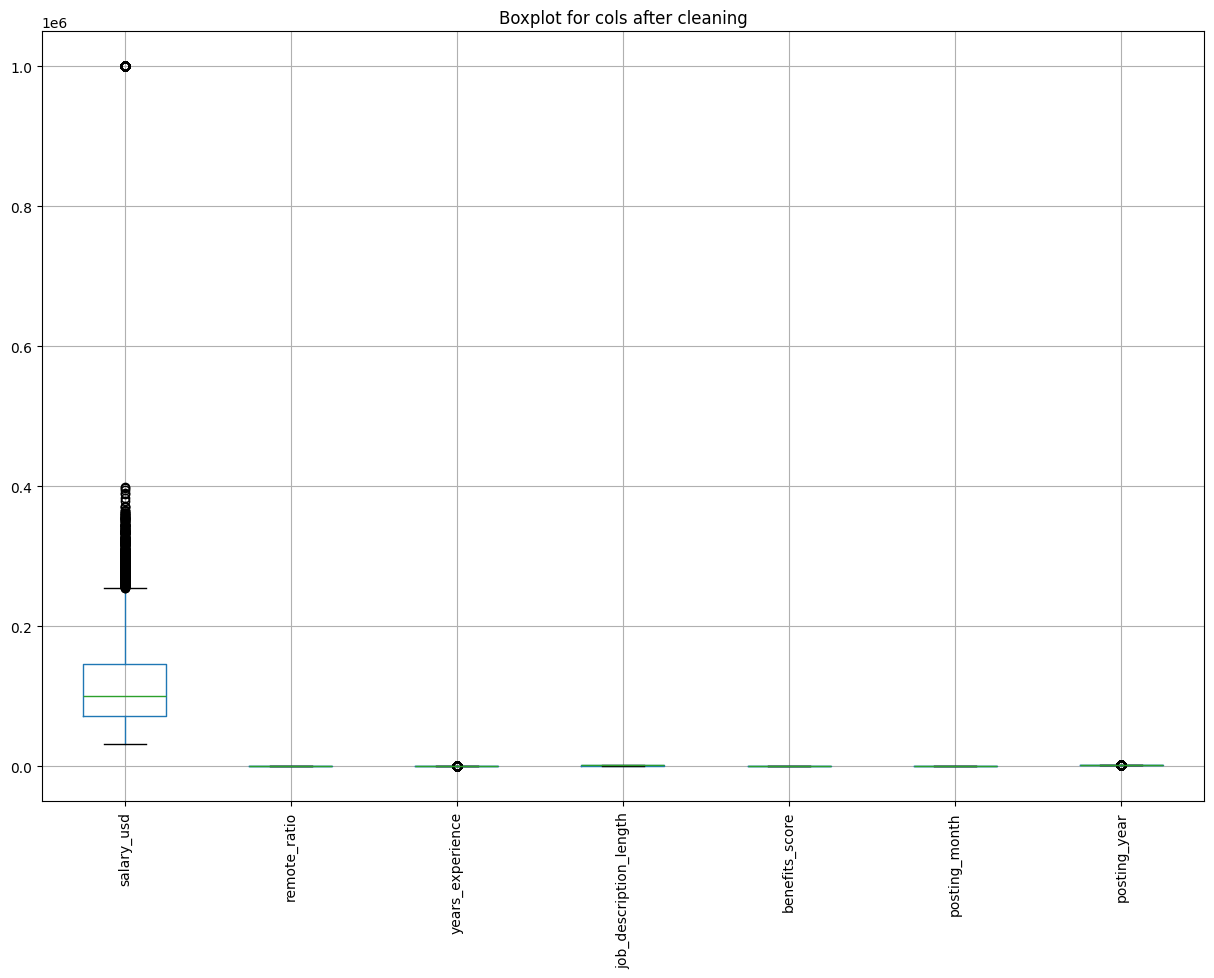

In [5]:
# re_check missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

# check outliers by boxplot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
df.boxplot(figsize=(15, 10))
plt.title('Boxplot for cols after cleaning')
plt.xticks(rotation=90)
plt.show()

## 5. Checking Missing Values and Outliers

**Findings:**

**Missing values:** All columns are clean (0 missing).

**Outliers (Boxplot):**

Significant outliers detected in salary_usd (values > 400k).

Other variables (e.g., `years_experience`, `benefits_score`, `remote_ratio`) show relatively stable distributions.

**Interpretation:**

The dataset is free from missing data, ensuring high reliability.

Salary outliers are notable and require attention in subsequent analysis (e.g., log transformation, winsorization, or separate treatment for high-earners).

(152, 23)


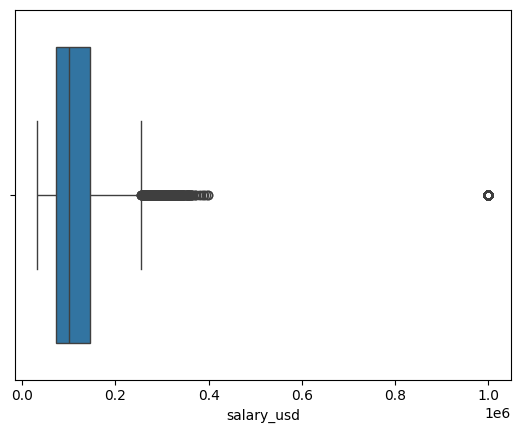

In [6]:
# Checking potential outliers in salary_usd
print(df[df['salary_usd'] == 999999].shape)

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['salary_usd'])
plt.show()

In [7]:
df = df[df['salary_usd'] != 999999]

**Findings:**

A total of 152 rows have salary_usd = 999,999, representing ~1% of the dataset.

These values are far above the general salary distribution (mean ≈ 123k, Q3 ≈ 145k).

The boxplot visualization confirms these are extreme outliers, separated from the main salary distribution.

**Interpretation:** It is highly likely that these 999k values were inserted as placeholders or errors during data collection. They do not represent realistic AI job salaries.

**Decision:** To ensure accurate analysis, these records will be removed (dropped) from the dataset.

## Section: Univariate Analysis

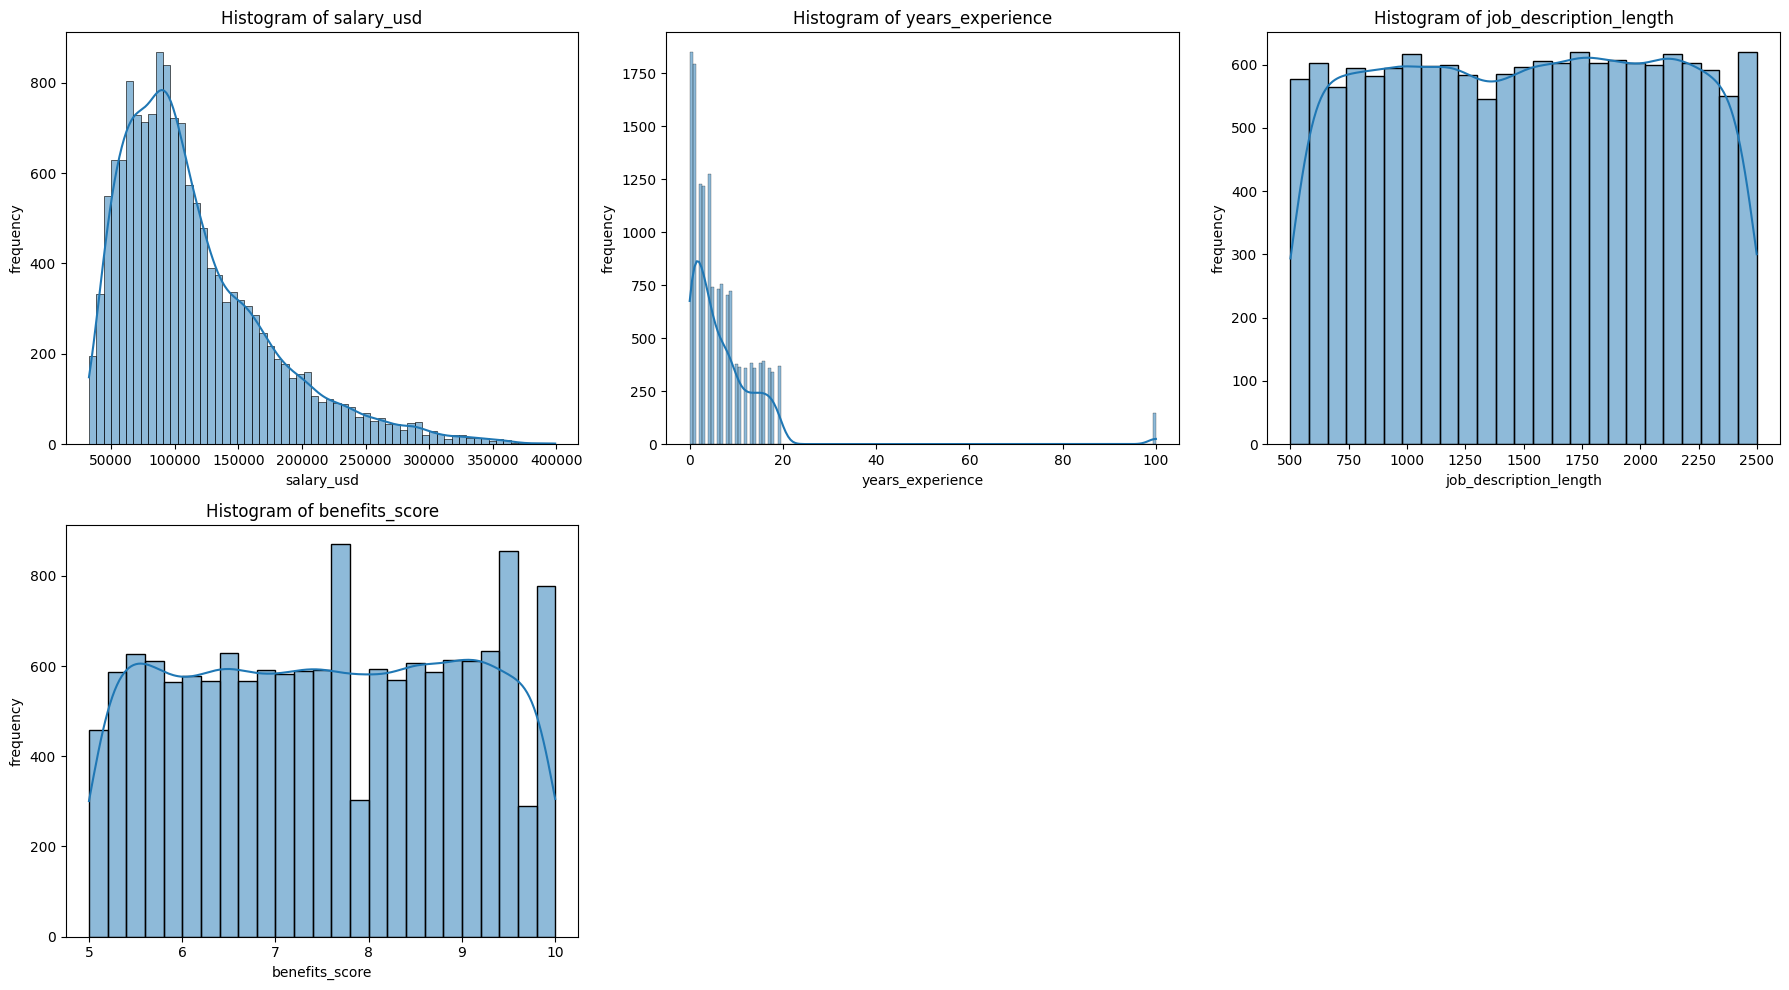

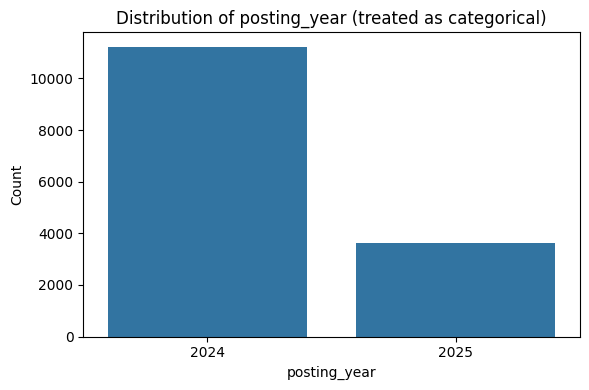

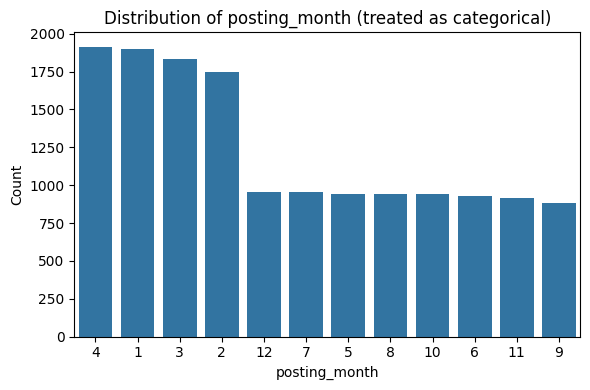

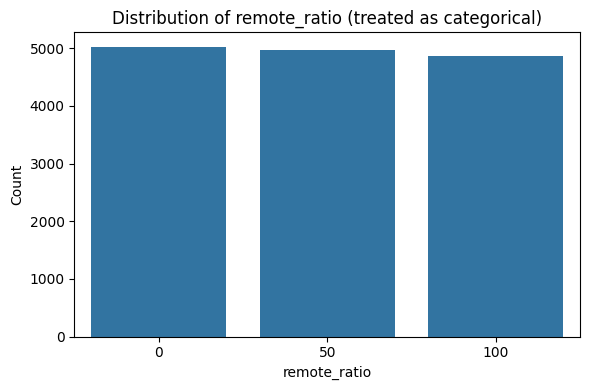

In [8]:
import numpy as np

# Function to draw histogram for all num cols
def plot_histograms(df, numerical_cols, exclude=None, bins=30, kde=True):
    if exclude is not None:
        ex = set(exclude)
        numerical_cols = [c for c in numerical_cols if c not in ex]
    
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = np.array(axes).ravel()
    
    for i, col in enumerate(numerical_cols):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('frequency')
    
    # Hide redundant subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_discrete_as_categorical(df, cols):
    for col in cols:
        plt.figure(figsize=(6,4))
        order = df[col].value_counts().index  # order by frequency
        sns.countplot(x=df[col], order=order)
        plt.title(f'Distribution of {col} (treated as categorical)')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

# Get lists
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

discrete_numeric = ['posting_year', 'posting_month', 'remote_ratio']

plot_histograms(df, numerical_cols, exclude=discrete_numeric, bins=30, kde=True)

plot_discrete_as_categorical(df, discrete_numeric)

### 1. Salary (USD)

**Purpose:** Explore the distribution of AI job salaries.

**Findings:** The distribution is strongly right-skewed. Most salaries are concentrated between 70k–150k USD, with a long tail extending beyond 400k.

**Interpretation:** The skewness indicates the presence of very high-paying jobs (outliers). A log transformation may be useful in later analysis to normalize the distribution.

### 2. Remote Ratio

**Purpose:** Analyze the distribution of remote work levels (0%, 50%, 100%).

**Findings:** The variable is multimodal, with three clear peaks at 0%, 50%, and 100%.

**Interpretation:** This suggests companies tend to adopt fixed remote policies (fully onsite, hybrid, or fully remote), rather than varied ratios.

### 3. Years of Experience

**Purpose:** Assess how many years of experience are typically required.

**Findings:** Most job postings require 0–10 years of experience, with a sharp drop afterward. Very few postings exceed 20 years.

**Interpretation:** The majority of AI jobs are targeted toward early- to mid-career professionals, aligning with the rapidly evolving nature of the field.

### 4. Job Description Length

**Purpose:** Examine the text length of job postings.

**Findings:** Distribution is roughly uniform between 500–2,500 characters, without extreme skewness.

**Interpretation:** Companies provide descriptions of varied but fairly standardized lengths, likely reflecting job board posting constraints.

### 5. Benefits Score

**Purpose:** Measure the quality of benefits associated with jobs.

**Findings:** Scores range from 5 to 10, with most clustered between 6–9.

**Interpretation:** Benefits are generally rated positively across postings, but limited variation reduces its power for deeper differentiation.

### 6. Posting Month

**Purpose:** Identify seasonal posting patterns.

**Findings:** Job postings occur throughout the year, but peaks appear around January–April.

**Interpretation:** Hiring in AI tends to cluster around the beginning and end of the year, possibly linked to budget cycles and project kickoffs.

### 7. Posting Year

**Purpose:** Confirm the time span of the dataset.

**Findings:** Most postings fall in 2024–2025, with 2025 slightly increasing.

**Interpretation:** The dataset is current and reflects recent job market trends, making it reliable for drawing insights into the near-term AI employment landscape.

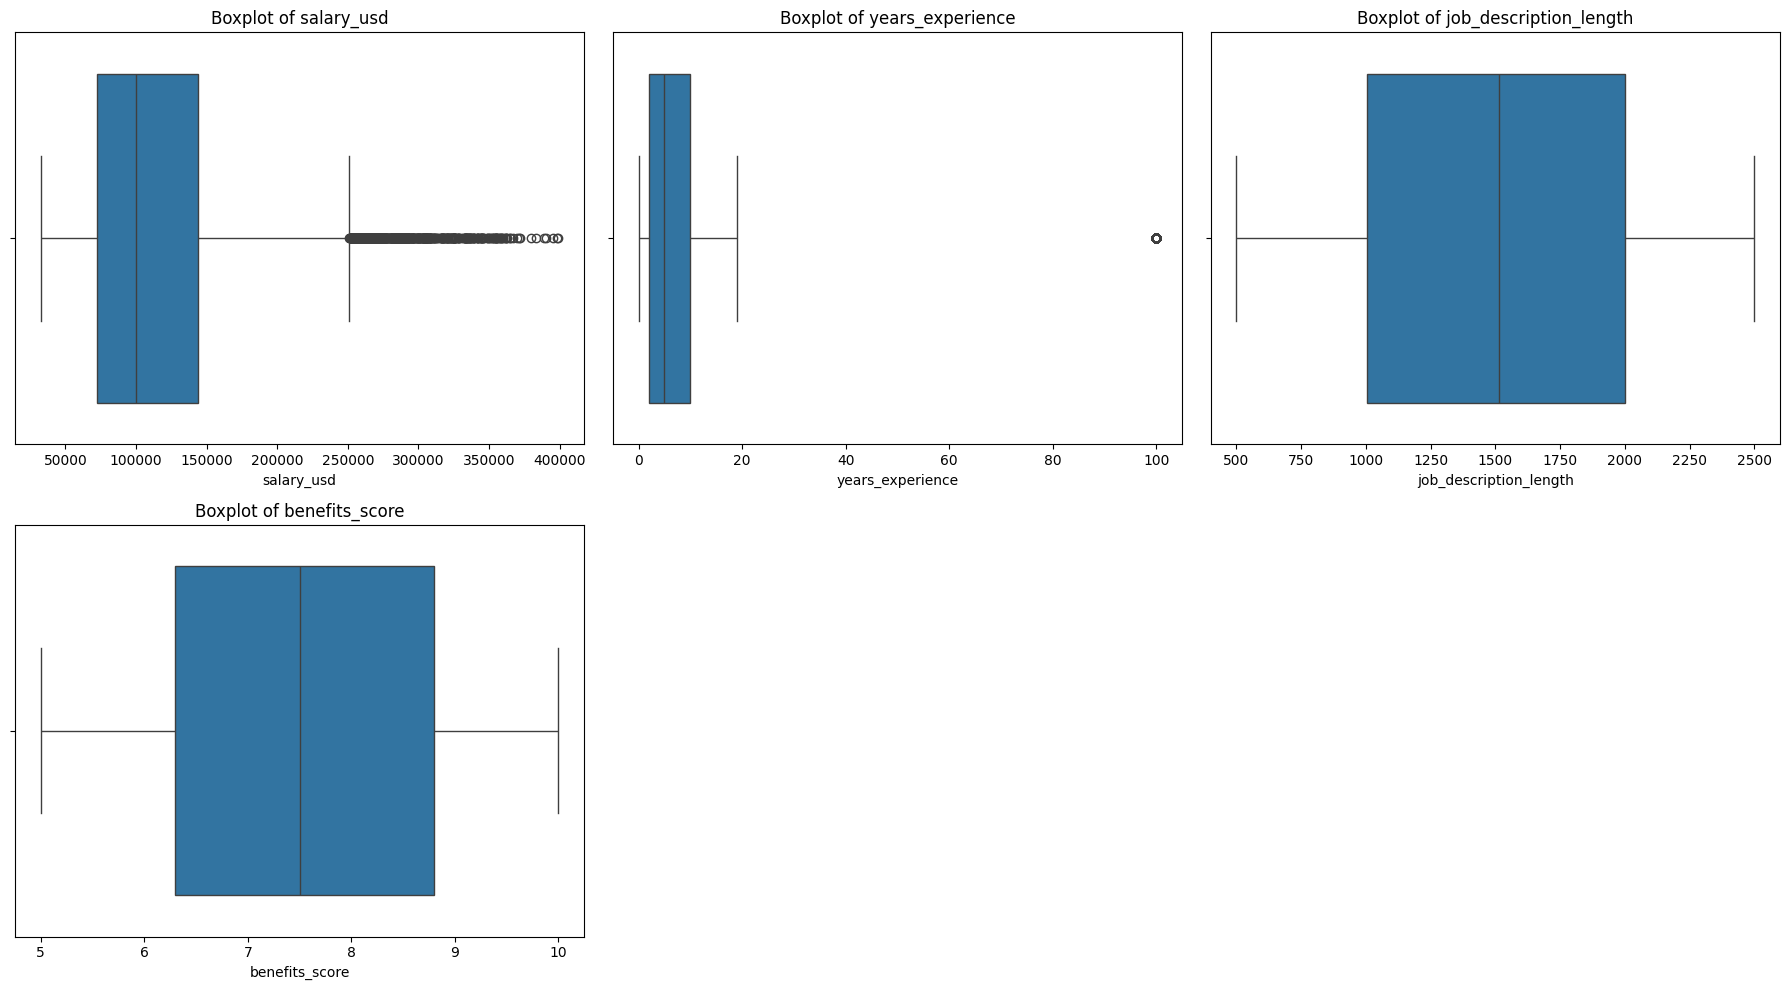

In [9]:
# Function to draw box plot for all num cols
def plot_boxplots(df, numerical_cols, exclude=None):
    if exclude is not None:
        ex = set(exclude)
        numerical_cols = [c for c in numerical_cols if c not in ex]

    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = np.array(axes).ravel()

    for i, col in enumerate(numerical_cols):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f'Boxplot of {col}')
        axes[i].set_xlabel(col)

    # # Hide redundant subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# Get list
plot_boxplots(df, numerical_cols, exclude=discrete_numeric)

In [10]:
# Checking potential outliers in year_experience
print(df[df['years_experience'] == 100].shape)

(149, 23)


In [11]:
df = df[df['years_experience'] != 100]

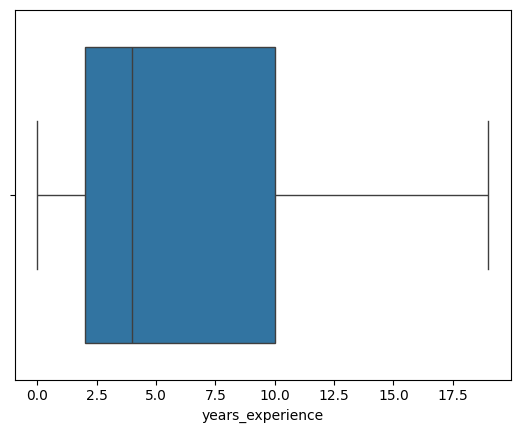

In [12]:
sns.boxplot(x=df['years_experience'])
plt.show()

In [13]:
# Caculate statistic metrics for numerical variables
stats_df = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std Dev': df[numerical_cols].std(),
    'Min': df[numerical_cols].min(),
    'Max': df[numerical_cols].max(),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurt()
})

print(stats_df)

                                 Mean   Median       Std Dev      Min  \
salary_usd              114830.388980  99928.0  58982.817533  32519.0   
remote_ratio                49.503705     50.0     40.789877      0.0   
years_experience             6.246040      4.0      5.542617      0.0   
job_description_length    1504.101163   1512.0    576.106073    500.0   
benefits_score               7.502128      7.5      1.449874      5.0   
posting_month                5.520362      5.0      3.501245      1.0   
posting_year              2024.243864   2024.0      0.429426   2024.0   

                             Max  Skewness  Kurtosis  
salary_usd              399095.0  1.308449  1.818553  
remote_ratio               100.0  0.018222 -1.497206  
years_experience            19.0  0.780376 -0.522691  
job_description_length    2499.0 -0.013467 -1.197213  
benefits_score              10.0 -0.006120 -1.207476  
posting_month               12.0  0.412917 -1.115760  
posting_year              2025

**Technical Interpretation**

**Salary (USD):**

*Mean* ≈ 114,830 USD, Median ≈ 99,928 USD → distribution is right-skewed (Skewness > 1).

*Std Dev* ≈ 59,883 → salaries vary widely across positions.

*Kurtosis* ≈ 1.8 → presence of many outliers at the high-salary end.

**Years of Experience:**

*Mean* ≈ 6.2 years, Median ≈ 4 years → most requirements are within 0–10 years.

*Skewness* ≈ 0.78 → slightly right-skewed (majority of postings require fewer years, with a smaller number requiring extensive experience).

**Job Description Length:**

*Average* ≈ 1,504 characters, ranging from 500–2,499 → fairly standardized.

*Skewness* ≈ 0 → balanced distribution.

**Benefits Score:**

*Mean* ≈ 7.5/10, clustered between 5–10.

*Skewness* ≈ 0 → benefits are consistently rated, with little variation.

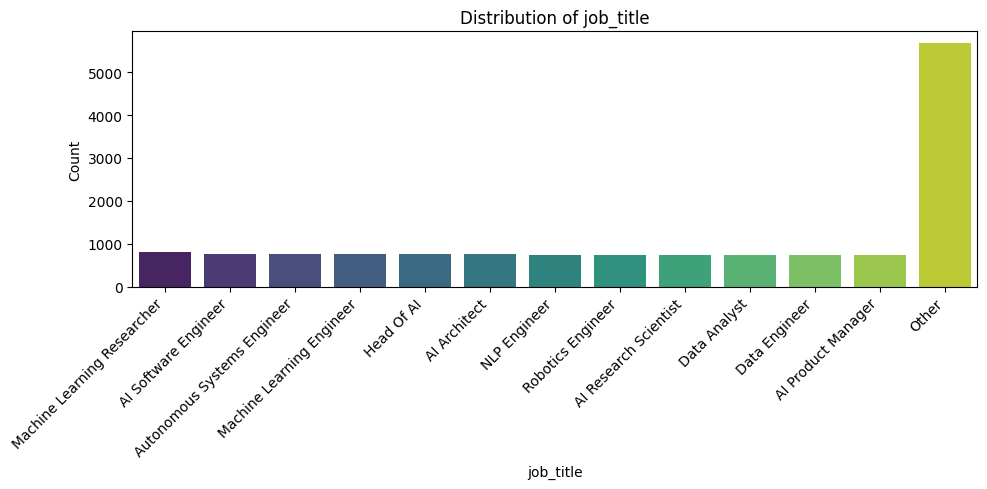

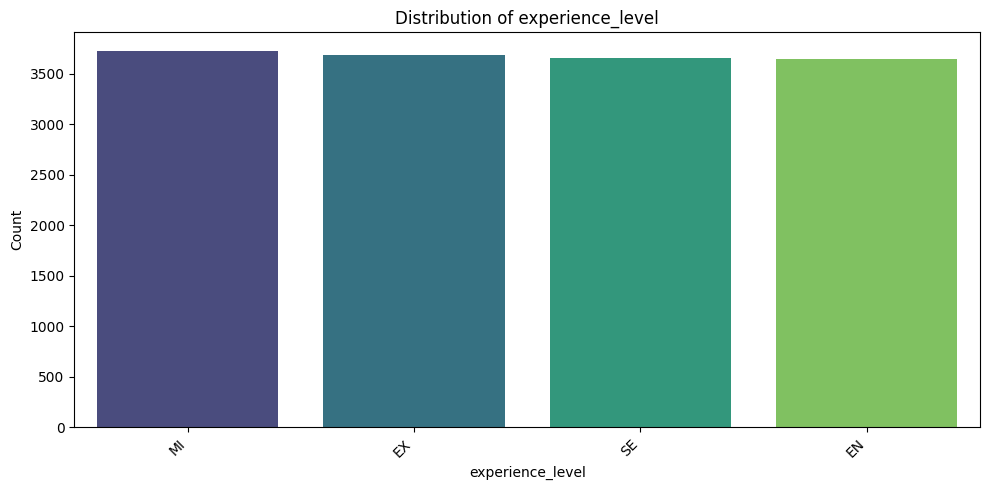

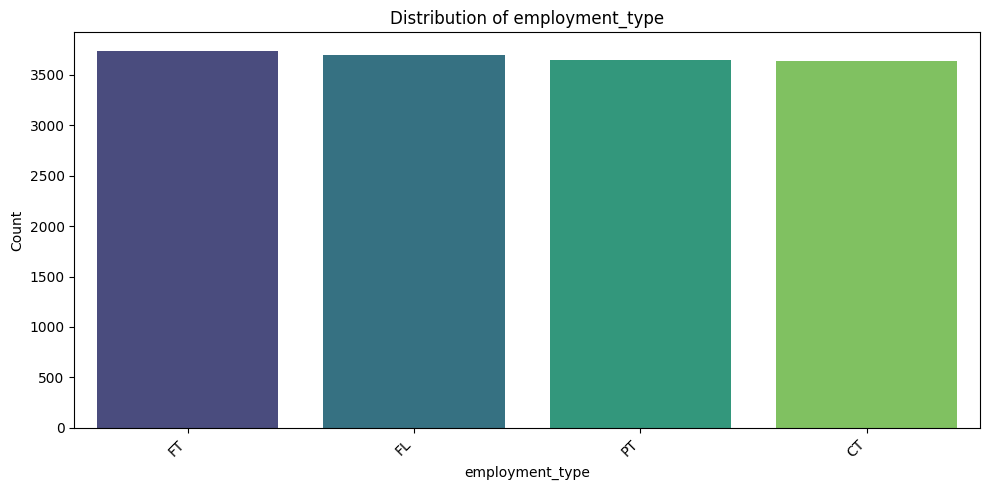

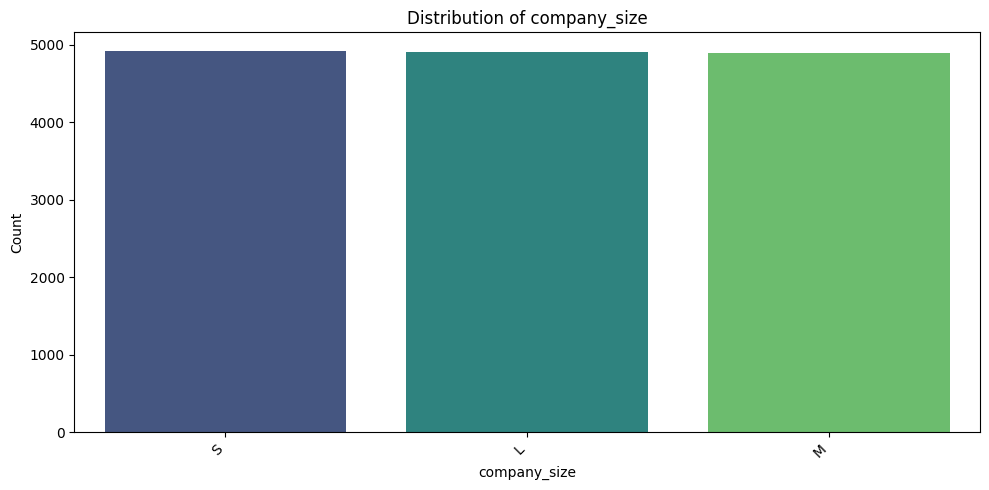

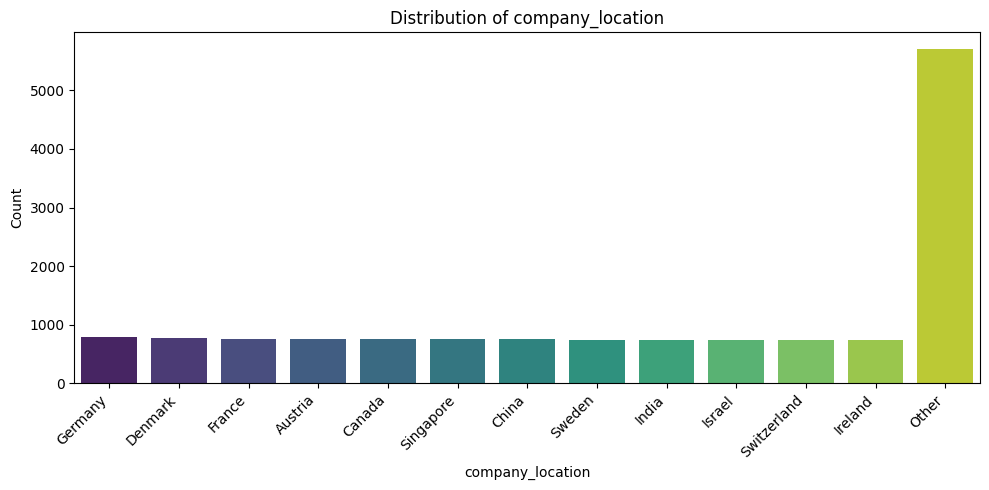

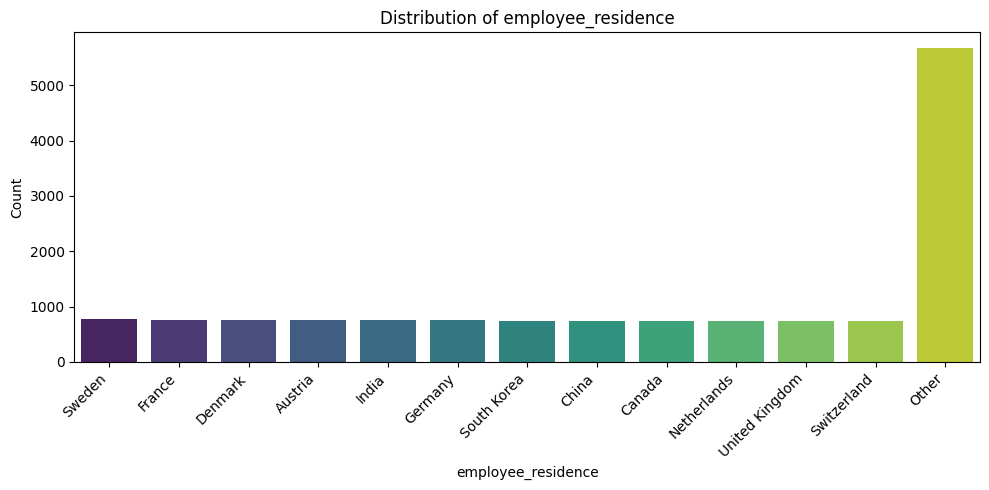

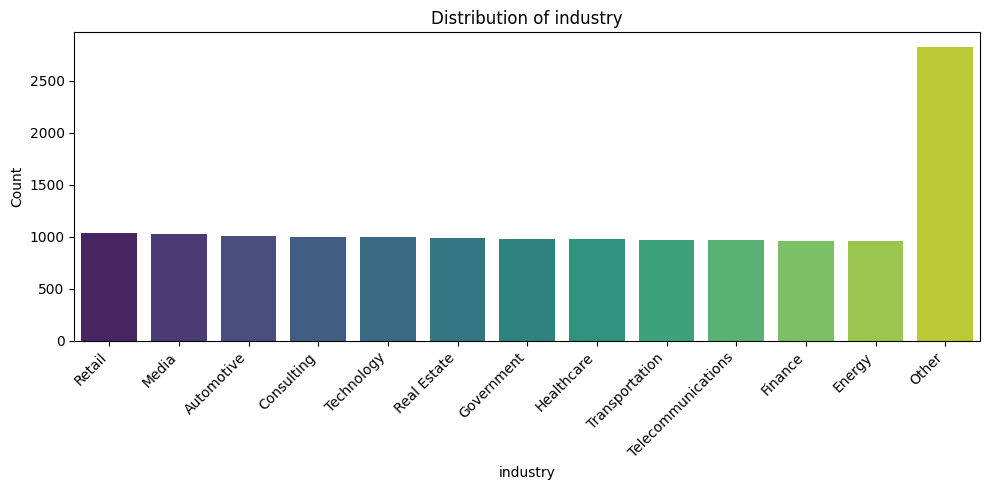

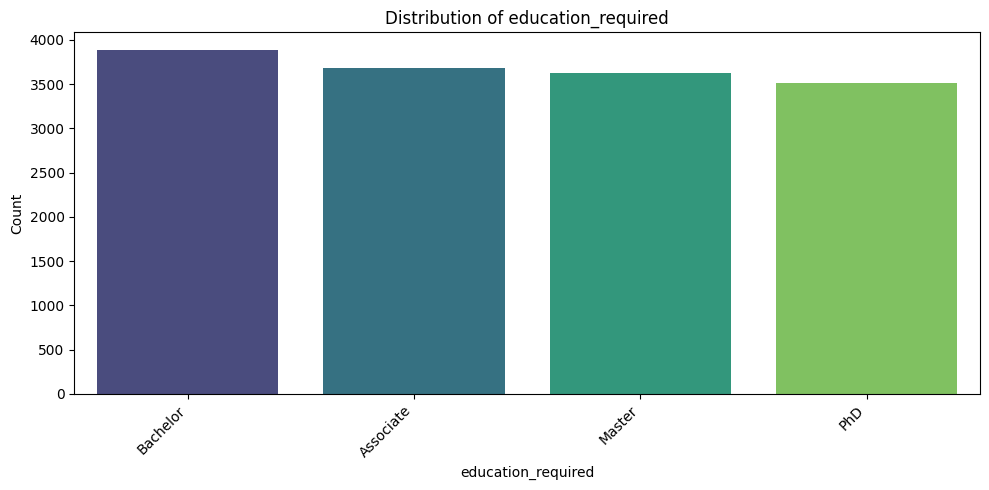

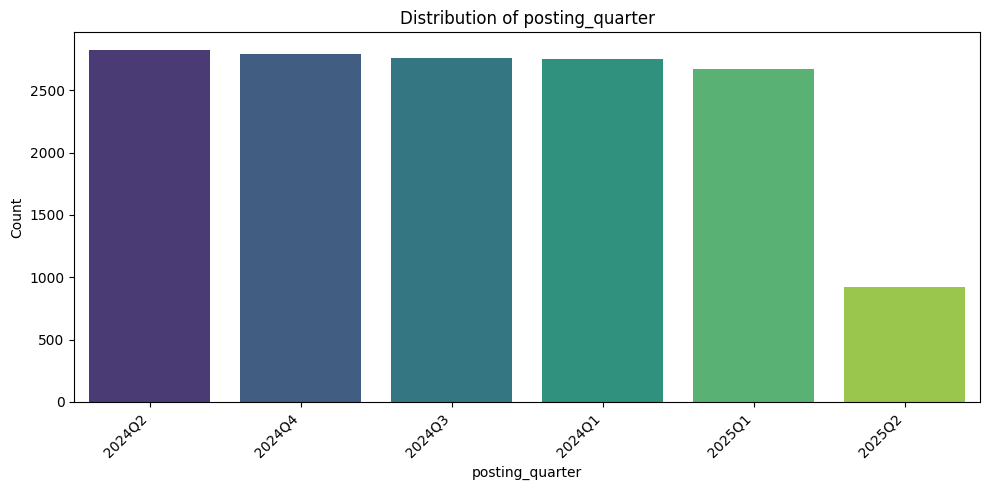

In [15]:
# Choose important categorical columns
categorical_cols = [
    'job_title', 'experience_level', 'employment_type',
    'company_size', 'company_location', 'employee_residence',
    'industry', 'education_required', 'posting_quarter'
]

def plot_categorical_bars(df, cat_cols, top_n=12):
    for col in cat_cols:
        plt.figure(figsize=(10,5))

        # Get frequency
        vc = df[col].value_counts()

        # If too much categories, just keep Top-N
        if len(vc) > top_n:
            other_sum = vc.iloc[top_n:].sum()
            vc = pd.concat([vc.iloc[:top_n], pd.Series({'Other': other_sum})])


        sns.barplot(x=vc.index, y=vc.values, palette="viridis")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Get function
plot_categorical_bars(df, categorical_cols, top_n=12)

In [16]:
for col in ['experience_level','employment_type','company_size']:
    print(f"\n{col} distribution (%):")
    print(df[col].value_counts(normalize=True)*100)


experience_level distribution (%):
experience_level
MI    25.304236
EX    25.066286
SE    24.841934
EN    24.787545
Name: proportion, dtype: float64

employment_type distribution (%):
employment_type
FT    25.392617
FL    25.100279
PT    24.767149
CT    24.739955
Name: proportion, dtype: float64

company_size distribution (%):
company_size
S    33.401319
L    33.353729
M    33.244952
Name: proportion, dtype: float64


**Intergretation**  

* The distributions of `experience_level`, `employment_type`, and `company_size` are nearly uniform across categories (~25–33%).

* This suggests that the dataset is balanced by design, likely to ensure fairness in comparative analysis across categories.

* While this helps avoid bias and allows clean comparisons, it may not fully reflect real-world labor market imbalances, where certain categories (e.g., Full-time jobs, Senior roles, Large companies) usually dominate.

In [24]:
# Create frequency and percentage tables for categorical variables
def create_cat_summary(df, categorical_cols):
    summary_list = []
    
    for col in categorical_cols:
        freq = df[col].value_counts()
        percent = df[col].value_counts(normalize=True) * 100
        
        summary_df = pd.DataFrame({
            'Variable': col,
            'Category': freq.index,
            'Frequency': freq.values,
            'Percentage': percent.values.round(2)
        })
        
        summary_list.append(summary_df)
    
    # concat all in a table
    combined_summary = pd.concat(summary_list, ignore_index=True)
    
    return combined_summary

# Get function
cat_summary = create_cat_summary(df, categorical_cols)
print(cat_summary)

           Variable                     Category  Frequency  Percentage
0         job_title  Machine Learning Researcher        797        5.42
1         job_title         AI Software Engineer        768        5.22
2         job_title  Autonomous Systems Engineer        762        5.18
3         job_title    Machine Learning Engineer        758        5.15
4         job_title                   Head Of AI        757        5.15
..              ...                          ...        ...         ...
91  posting_quarter                       2024Q4       2787       18.95
92  posting_quarter                       2024Q3       2758       18.75
93  posting_quarter                       2024Q1       2754       18.72
94  posting_quarter                       2025Q1       2667       18.13
95  posting_quarter                       2025Q2        920        6.25

[96 rows x 4 columns]


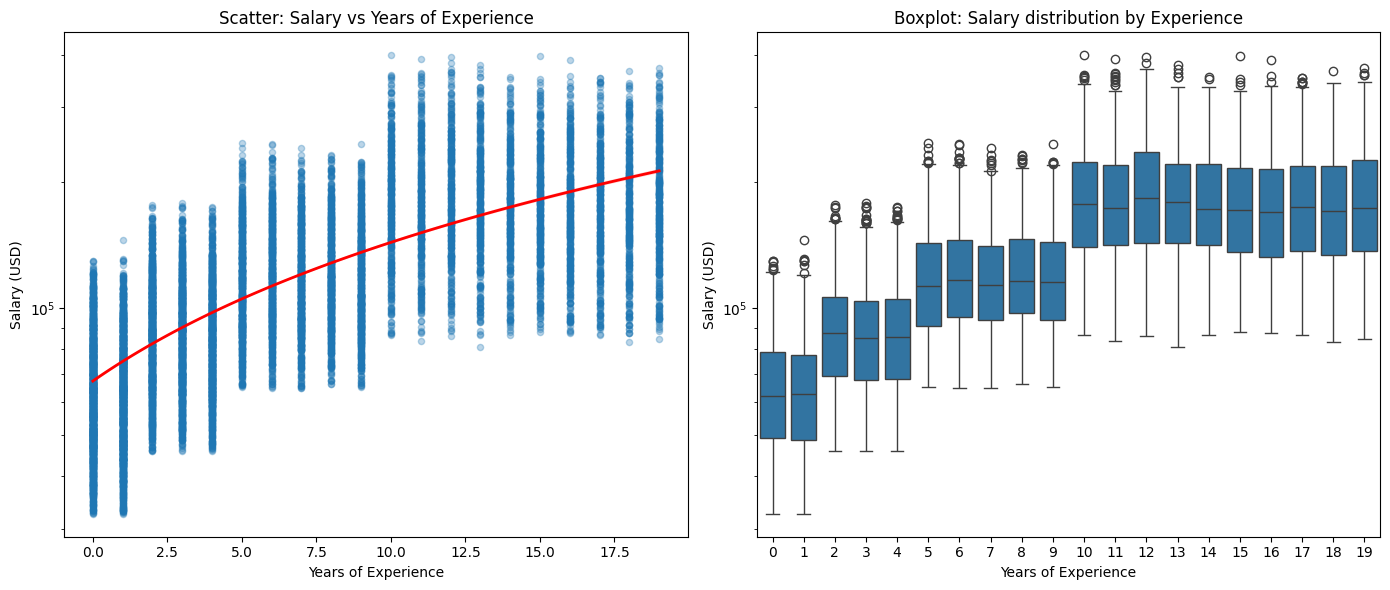

In [29]:
continuous_numeric = ['salary_usd','years_experience','job_description_length','benefits_score']


plt.figure(figsize=(14,6))

# ---- 1. Scatter plot + regression ----
plt.subplot(1,2,1)
sns.regplot(
    data=df, 
    x='years_experience', 
    y='salary_usd',
    scatter_kws={'alpha':0.3, 's':20},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Scatter: Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (USD)')
plt.yscale('log')  

# ---- 2. Boxplot ----
plt.subplot(1,2,2)
sns.boxplot(
    data=df, 
    x='years_experience', 
    y='salary_usd'
)
plt.title('Boxplot: Salary distribution by Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (USD)')
plt.yscale('log')   

plt.tight_layout()
plt.show()

In [37]:
df[['years_experience','salary_usd']].corr(method='spearman')

,years_experience,salary_usd
years_experience,1.000000,0.769922
salary_usd,0.769922,1.000000


**Cell: Salary vs Years of Experience**

**Purpose:** Examine how salaries vary with years of experience.

**Findings:** Both scatter and boxplots show a strong positive relationship between experience and salary (ρ ≈ 0.77). Median salary rises steadily up to ~10 years, then begins to plateau. Senior-level roles (>10 years) show higher variability, with some extreme outliers at very high salaries.

**Interpretation:** Experience is a major driver of compensation. However, salary growth slows after ~10 years, and variation becomes larger, suggesting that beyond a certain threshold, niche expertise or leadership roles rather than tenure drive salary differences.

In [34]:
df[['benefits_score','salary_usd']].corr(method='spearman')

,benefits_score,salary_usd
benefits_score,1.000000,-0.005034
salary_usd,-0.005034,1.000000


**Cell: Salary vs Benefit Score**

**Purpose:** Explore relationship between salary and benefits.

**Findings:** Spearman ρ ≈ -0.005.

**Interpretation:** Benefits packages (5–10 range) do not significantly influence salary levels. Compensation strategy likely treats salary and benefits as separate levers.

**Note:** Correlation is negligible (ρ ≈ -0.005), thus no meaningful visual analysis was performed.

In [39]:
df[['job_description_length','salary_usd']].corr(method='spearman')

,job_description_length,salary_usd
job_description_length,1.000000,-0.010349
salary_usd,-0.010349,1.000000


**Cell: Salary vs Benefit Score**

**Purpose:** Explore relationship between salary and benefits.

**Findings:** Correlation coefficient ≈ -0.01, essentially zero.

**Interpretation:** Job description length does not influence salary. Companies with longer or shorter postings do not show systematic differences in pay.

**Note:** Correlation is negligible (ρ ≈ -0.01), thus no meaningful visual analysis was performed.

In [43]:
df[['years_experience','benefits_score']].corr(method='spearman')

,years_experience,benefits_score
years_experience,1.000000,-0.010803
benefits_score,-0.010803,1.000000


**Cell: Years Experience vs Benefit Score**

**Purpose:** Explore relationship between experience and benefits.

**Findings:** Correlation coefficient ≈ -0.01, essentially zero.

**Interpretation:** Years Experience does not influence Benefits Score. This suggests that companies tend to design uniform benefits for all employees, and differentiate compensation mainly through salary rather than benefits.

**Note:** Correlation is negligible (ρ ≈ -0.01), thus no meaningful visual analysis was performed.

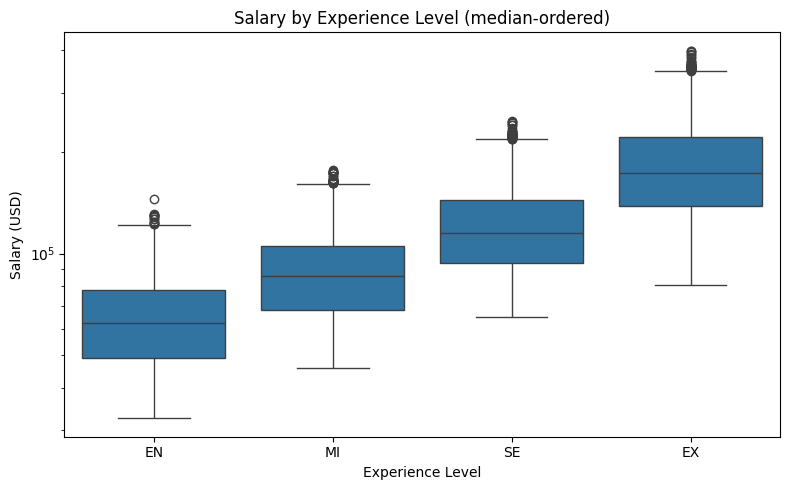

                  count    median           mean
experience_level                                
EN                 3646   62135.0   65217.344899
MI                 3722   86021.0   88653.375739
SE                 3654  115031.0  121364.819239
EX                 3687  173523.0  183841.290480


In [47]:
dfc = df.copy()

# Use log-scale for salary to descrease the effective of outliers
USE_LOG = True

plt.figure(figsize=(8,5))
order = dfc.groupby('experience_level')['salary_usd'].median().sort_values().index
sns.boxplot(data=dfc, x='experience_level', y='salary_usd', order=order)
plt.title('Salary by Experience Level (median-ordered)')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
if USE_LOG: plt.yscale('log')
plt.tight_layout(); plt.show()

print(dfc.groupby('experience_level')['salary_usd']
      .agg(['count','median','mean']).sort_values('median'))

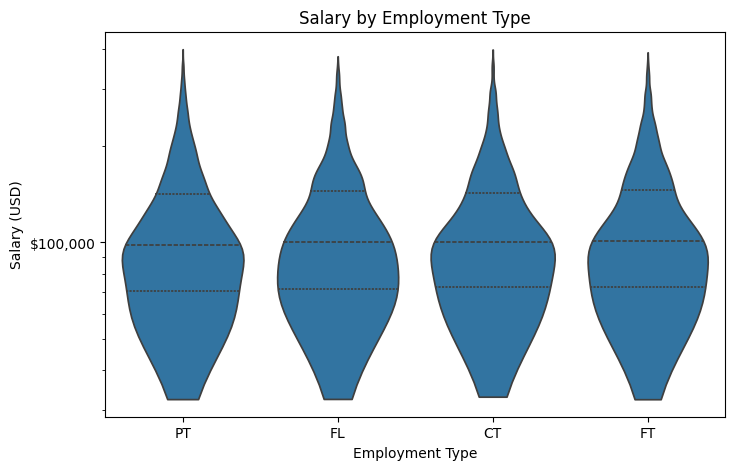

In [65]:
import matplotlib.ticker as mtick

plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='employment_type', y='salary_usd', order=order, cut=0, inner='quartile')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.title('Salary by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Salary (USD)')
plt.show()

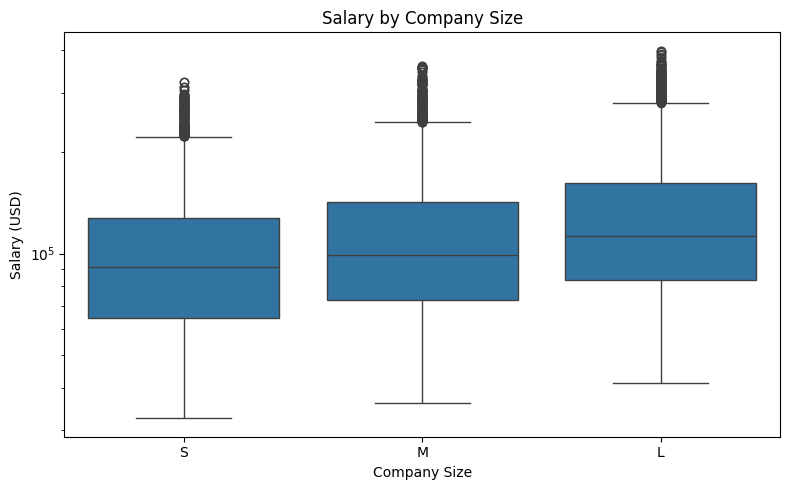

In [49]:
plt.figure(figsize=(8,5))
order = dfc.groupby('company_size')['salary_usd'].median().sort_values().index
sns.boxplot(data=dfc, x='company_size', y='salary_usd', order=order)
plt.title('Salary by Company Size'); plt.xlabel('Company Size'); plt.ylabel('Salary (USD)')
if USE_LOG: plt.yscale('log')
plt.tight_layout(); plt.show()

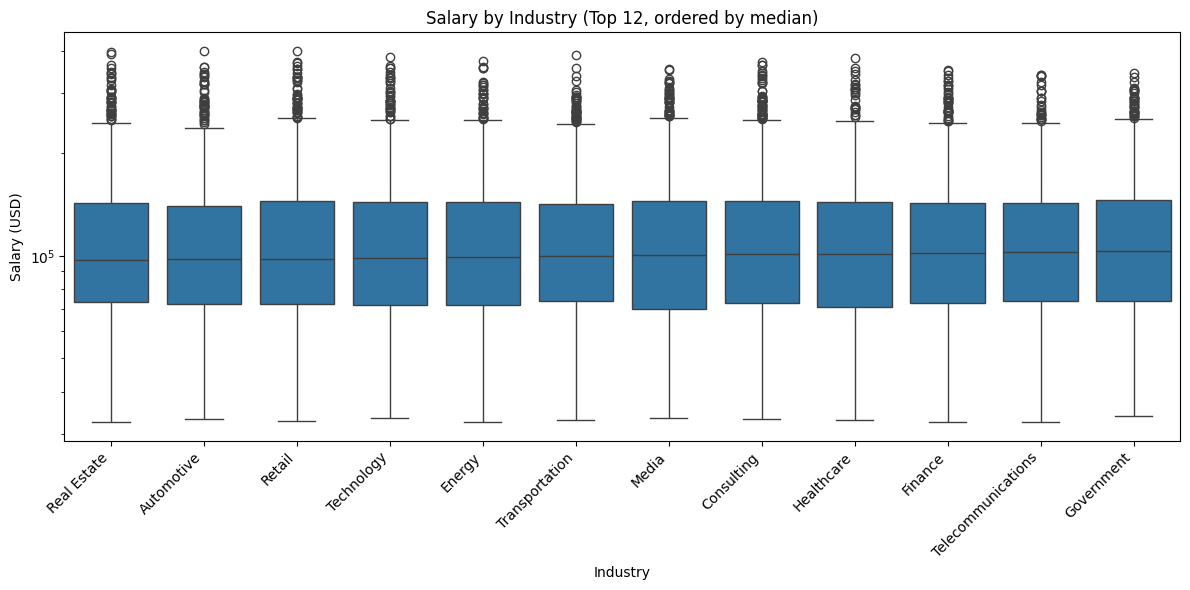

In [51]:
top_ind = dfc['industry'].value_counts().head(12).index
tmp = dfc[dfc['industry'].isin(top_ind)]
order = tmp.groupby('industry')['salary_usd'].median().sort_values().index

plt.figure(figsize=(12,6))
sns.boxplot(data=tmp, x='industry', y='salary_usd', order=order)
plt.title('Salary by Industry (Top 12, ordered by median)')
plt.xlabel('Industry'); plt.ylabel('Salary (USD)')
plt.xticks(rotation=45, ha='right'); 
if USE_LOG: plt.yscale('log')
plt.tight_layout(); plt.show()

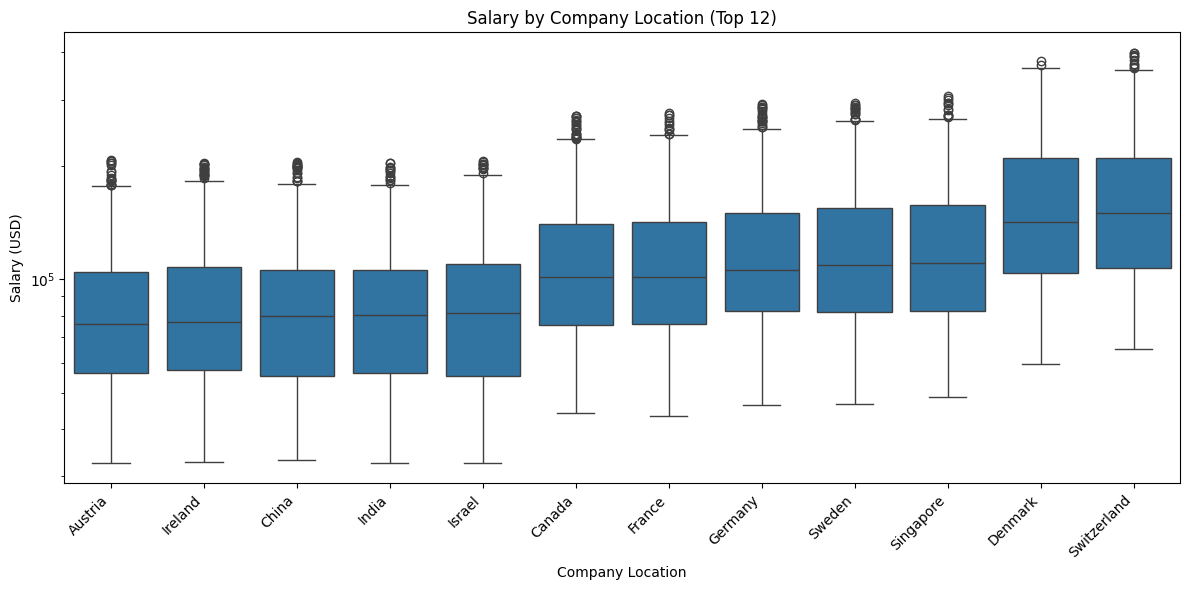

In [55]:
top_loc = dfc['company_location'].value_counts().head(12).index
tmp = dfc[dfc['company_location'].isin(top_loc)]
order = tmp.groupby('company_location')['salary_usd'].median().sort_values().index

plt.figure(figsize=(12,6))
sns.boxplot(data=tmp, x='company_location', y='salary_usd', order=order)
plt.title('Salary by Company Location (Top 12)')
plt.xlabel('Company Location'); plt.ylabel('Salary (USD)')
plt.xticks(rotation=45, ha='right')
if USE_LOG: plt.yscale('log')
plt.tight_layout(); plt.show()

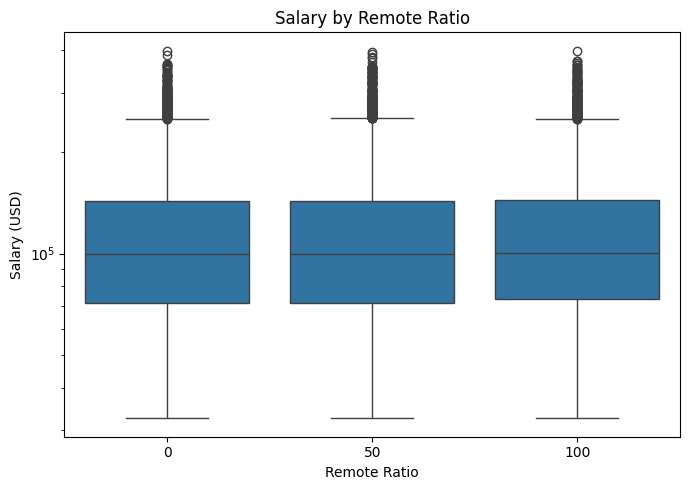

In [56]:
plt.figure(figsize=(7,5))
order = [0,50,100]
sns.boxplot(data=dfc, x='remote_ratio', y='salary_usd', order=order)
plt.title('Salary by Remote Ratio'); plt.xlabel('Remote Ratio'); plt.ylabel('Salary (USD)')
if USE_LOG: plt.yscale('log')
plt.tight_layout(); plt.show()

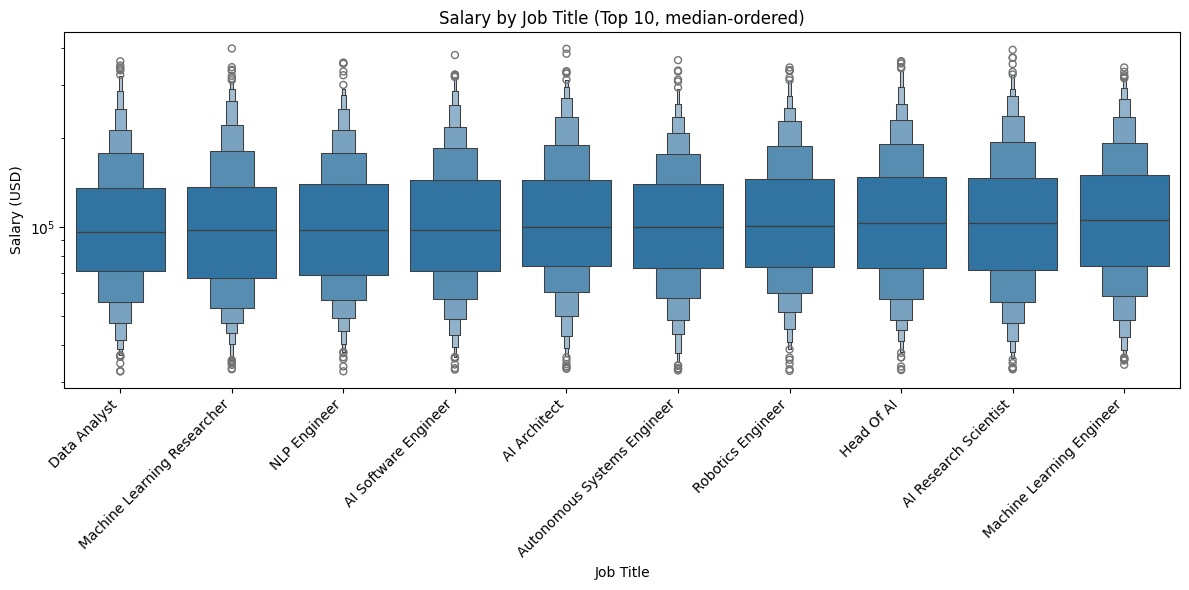

In [59]:
top_titles = dfc['job_title'].value_counts().head(10).index
tmp = dfc[dfc['job_title'].isin(top_titles)]
order = tmp.groupby('job_title')['salary_usd'].median().sort_values().index

plt.figure(figsize=(12,6))
sns.boxenplot(data=tmp, x='job_title', y='salary_usd', order=order)
plt.title('Salary by Job Title (Top 10, median-ordered)')
plt.xlabel('Job Title'); plt.ylabel('Salary (USD)')
plt.xticks(rotation=45, ha='right')
if USE_LOG: plt.yscale('log')
plt.tight_layout(); plt.show()